# RLSSM — Basic tutorial

**Reinforcement-Learning Sequential Sampling Models (RLSSMs)** join two ideas that
cognitive scientists usually study separately:

1. a **learning process** — how a participant updates their expectations from
   trial-to-trial feedback (here, the Rescorla–Wagner rule); and
2. a **decision process** — how, on each trial, those expectations are turned into
   an actual *choice* and a *response time* (here, a drift-diffusion–style
   sequential sampling model).

A plain RL model explains *which* option is chosen but ignores *how long* the choice
took. A plain SSM explains the choice/RT on a single decision but assumes the
decision variables are fixed. An RLSSM closes the loop: the value a participant has
*learned* becomes the thing that *drives* the moment-to-moment decision, and it does
so on every trial. This lets us fit choices **and** response times jointly and
recover both the learning parameters (e.g. a learning rate) and the decision
parameters (e.g. boundary separation) from the same data.

This tutorial is written for readers who are **new to HSSM, PyMC, and RLSSMs**. We
will go slowly and explain each object as it appears. By the end you will have:

- simulated a synthetic RLSSM dataset with [`ssm-simulators`](https://github.com/lnccbrown/ssm-simulators) (`ssms.rl`),
- **bridged** that model into HSSM with a single call (`RLSSMConfig.from_ssms_model`),
- fit a **hierarchical** (multi-participant) model with PyMC under the hood,
- checked **parameter recovery** at the group *and* individual level, and
- run a **posterior predictive check** tailored to RLSSMs.

> **Where this sits in the suite:** this is the entry point. Later tutorials build
> *custom* learning/decision models
> ([Custom models with ssms.rl](rlssm_advanced.ipynb) ·
> [Restless learner](rlssm_restless_learner.ipynb)) and show HSSM-native
> registration ([Registering custom models in HSSM](rlssm_hssm_custom_models.ipynb)).

## 1. The idea in a bit more detail

### 1.1 The learning process: Rescorla–Wagner

Our task is a **two-armed bandit**: on each trial the participant picks one of two
options and receives binary feedback (reward = 1, no reward = 0). The participant
keeps a running value estimate $Q$ for each option and updates it using the
**Rescorla–Wagner delta rule**. After choosing option $c$ and observing reward $r$:

$$
Q_{c} \leftarrow Q_{c} + \alpha \, \underbrace{(r - Q_{c})}_{\text{prediction error}}
$$

- $Q_c$ is the current value estimate for the chosen option.
- $r - Q_c$ is the **reward prediction error** — how surprising the outcome was.
- $\alpha \in (0, 1)$ is the **learning rate** (`rl_alpha`): large $\alpha$ means the
  participant updates quickly and weights recent outcomes heavily; small $\alpha$
  means slow, stable learning. Only the chosen option's value is updated.

### 1.2 Coupling value to the decision: the drift rate

On each trial, the *difference* in learned value between the two options sets how
strongly evidence flows toward one option during the decision. Concretely the
**drift rate** $v$ of the decision process is

$$
v = \big(Q_{1} - Q_{0}\big)\cdot \texttt{scaler}
$$

where `scaler` converts a value difference into drift units. When the two options
look equally good ($Q_1 \approx Q_0$) drift is near zero and choices are slow and
near-chance; as learning separates the values, $|v|$ grows and choices become faster
and more consistent. **`v` is not a free parameter you estimate directly — it is
*computed* from the learning process on every trial.** This is the heart of an RLSSM.

### 1.3 The decision process: the angle SSM (brief)

Given a drift rate, the decision itself is produced by a **sequential sampling
model**. If you have seen the drift-diffusion model (DDM) before, this will be
familiar: noisy evidence accumulates from a starting point until it hits one of two
boundaries, and *which* boundary and *when* determine the choice and RT. We use the
**angle** variant, whose only addition to the standard DDM is a **linearly
collapsing boundary** — the decision threshold narrows over time, which helps capture
the fast errors often seen in speeded choice. Its parameters:

| Param | Meaning |
|-------|---------|
| `v` | drift rate — **computed** from learned value (see above), not free |
| `a` | boundary separation (how much evidence is needed) |
| `z` | starting-point bias (0.5 = unbiased) |
| `t` | non-decision time (encoding + motor, in seconds) |
| `theta` | boundary collapse angle (0 = standard DDM) |

We keep the SSM description short on purpose — the DDM family is covered in depth in
the other HSSM tutorials. The RLSSM-specific part is *only* the coupling in §1.2.

### 1.4 Why hierarchical?

We rarely have one participant; we have many, each slightly different. A
**hierarchical** model estimates a group-level value for each parameter **and** a
per-participant deviation from it, letting participants share statistical strength
("partial pooling"). We will specify exactly this below and then check that the
fitted model recovers both the group means and the individual differences we baked
into the simulation.

## 2. Setup

We import HSSM and the `ssms.rl` simulation API, then set two global options that
matter for RLSSM work:

- **`hssm.set_floatX("float32")`** — RLSSM likelihoods run through a JAX scan over
  trials; single precision keeps this fast and is what the RLSSM pipeline is tuned
  for.
- We silence a few noisy library warnings so the notebook output stays readable.

In [1]:
import logging
import os
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import hssm
import ssms.rl as rl

warnings.filterwarnings("ignore")
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)

hssm.set_floatX("float32", update_jax=True)
RANDOM_SEED = 20260704

Setting PyTensor floatX type to float32.


Setting "jax_enable_x64" to False. If this is not intended, please set `jax` to False.


### Simulation scale

Fitting a hierarchical RLSSM involves MCMC sampling, which is too heavy to run on
every documentation build. We therefore expose a single switch: the notebook runs at
a small **doc scale** by default, and at a fuller **`FULL_RUN`** scale (more
participants, trials, and draws) when the environment variable `FULL_RUN=1` is set.
The outputs committed to the docs come from a `FULL_RUN` execution.

In [2]:
FULL_RUN = os.environ.get("FULL_RUN", "0") == "1"

N_PARTICIPANTS = 15 if FULL_RUN else 5
N_TRIALS = 150 if FULL_RUN else 70
N_CHAINS = 2
N_TUNE = 1000 if FULL_RUN else 300
N_DRAWS = 500 if FULL_RUN else 300

print(f"FULL_RUN={FULL_RUN} | participants={N_PARTICIPANTS} trials={N_TRIALS} "
      f"tune={N_TUNE} draws={N_DRAWS}")

FULL_RUN=True | participants=15 trials=150 tune=1000 draws=500


## 3. Pick a model: the `2AB_RW_Angle` preset

`ssms.rl` ships **presets** that bundle a task environment, a learning rule, and a
decision process into one ready-to-use model. `2AB_RW_Angle` is exactly the model we
described in §1: a **2**-**a**rmed **b**andit with **R**escorla–**W**agner learning
and an **angle** decision process. `rl.preset.info(...)` prints a readable summary of
everything the preset contains.

In [3]:
ssms_config = rl.preset.get("2AB_RW_Angle")
print(rl.preset.info("2AB_RW_Angle"))

Preset: 2AB_RW_Angle
Description: Two-armed bandit with a Rescorla-Wagner delta-rule learner and an angle decision process.
Task: two-armed Bernoulli bandit
Learning process: RescorlaWagnerDeltaRule
Decision process: angle
Required parameters: rl_alpha, scaler, a, z, t, theta
Default parameters: rl_alpha=0.2, scaler=2, a=1, z=0.5, t=0.001, theta=0
Response labels: (-1, 1)
Response to choice: {-1: 0, 1: 1}
Context fields: ['feedback']
Learning backend: jax
Gradient support: available
HSSM participant contract: yes


A few fields to note in that summary:

- **Required parameters** are what we must supply to simulate: the learning
  parameters `rl_alpha`, `scaler` and the decision parameters `a`, `z`, `t`, `theta`.
  The drift `v` is *not* here — it is **computed** each trial from the learner.
- **Response labels** `(-1, 1)` are the two arms. In this preset arm `-1` is the
  *high-reward* arm (reward probability 0.7) and arm `1` is the low-reward arm (0.3).
- **Gradient support: available** means the learning process has a differentiable
  JAX implementation — a hard requirement for HSSM's gradient-based sampler. Let's
  confirm that explicitly:

In [4]:
assembled = ssms_config.assemble(backend="jax")
print("computed params (driven by the learner):", assembled.computed_params)
print("context fields (read from data each trial):", assembled.context_fields)
assert assembled.gradient == "available", "HSSM inference needs JAX gradients"

computed params (driven by the learner): ['v']
context fields (read from data each trial): ['feedback']


## 4. Define ground-truth parameters

Because this is a tutorial, we *simulate* data from known parameters so we can later
check whether the model recovers them. We choose a **group mean** for each parameter
and give each participant a small random deviation around that mean, so participants
genuinely differ — that is what the hierarchical model will try to recover.

`SDS` sets how spread out participants are for each parameter (bigger = more
individual variability), and `BOUNDS` keeps every sampled value inside the range the
model supports.

In [5]:
GROUP_THETA = {
    "rl_alpha": 0.08,   # learning rate (small -> gradual, visible learning)
    "scaler": 2.5,      # value-difference -> drift gain
    "a": 1.2,           # boundary separation
    "z": 0.5,           # starting-point bias (0.5 = unbiased)
    "t": 0.25,          # non-decision time (s)
    "theta": 0.35,      # boundary collapse angle
}
# Between-participant SD for each parameter (individual differences to recover).
SDS = {
    "rl_alpha": 0.03, "scaler": 0.40, "a": 0.20,
    "z": 0.06, "t": 0.05, "theta": 0.10,
}
# Keep sampled values inside supported ranges.
BOUNDS = {
    "rl_alpha": (0.01, 1.0), "scaler": (0.1, 5.0), "a": (0.3, 2.5),
    "z": (0.1, 0.9), "t": (0.05, 1.0), "theta": (0.0, 1.2),
}
LIST_PARAMS = list(GROUP_THETA)

rng = np.random.default_rng(RANDOM_SEED)
theta_arrays = {
    name: np.clip(rng.normal(GROUP_THETA[name], SDS[name], N_PARTICIPANTS),
                  *BOUNDS[name])
    for name in LIST_PARAMS
}

# One row per participant: their true parameter values (for the recovery check later).
true_params = pd.DataFrame(theta_arrays)
true_params.index.name = "participant_id"
true_params.round(3)

,rl_alpha,scaler,a,z,t,theta
participant_id,,,,,,
0,0.048,2.349,1.156,0.486,0.258,0.362
1,0.118,2.287,0.921,0.526,0.277,0.288
2,0.084,2.307,1.357,0.513,0.252,0.441
3,0.069,2.491,1.176,0.480,0.332,0.433
4,0.111,1.808,1.350,0.439,0.147,0.312
5,0.041,2.433,1.247,0.555,0.255,0.485
6,0.085,1.841,1.209,0.443,0.263,0.389
7,0.071,3.062,1.203,0.546,0.225,0.096
8,0.112,1.977,0.989,0.498,0.258,0.305


## 5. Simulate the data

`rl.Simulator(config).simulate(...)` runs the full generative loop for every
participant and trial: compute the drift from current Q-values → run the angle SSM to
get a choice and RT → deliver feedback → update the Q-values. Passing **arrays** of
parameters (one value per participant) produces a balanced multi-participant panel.

In [6]:
data = rl.Simulator(ssms_config).simulate(
    theta=theta_arrays,
    n_trials=N_TRIALS,
    n_participants=N_PARTICIPANTS,
    random_state=RANDOM_SEED,
)
# Validate the panel matches what the model expects before doing anything else.
ssms_config.validate_data(data).raise_for_errors()

print("rows:", len(data), "| columns:", list(data.columns))
data.head()

rows: 2250 | columns: ['participant_id', 'trial_id', 'rt', 'response', 'feedback']


,participant_id,trial_id,rt,response,feedback
0,0,0,1.069821,-1,1.0
1,0,1,1.998447,-1,1.0
2,0,2,1.560222,-1,1.0
3,0,3,0.505802,-1,1.0
4,0,4,1.074383,-1,1.0


Each row is one trial. The columns we care about:

- **`participant_id`, `trial_id`** — who and when.
- **`response`** — the chosen arm (`-1` or `1`).
- **`rt`** — the response time in seconds.
- **`feedback`** — the reward delivered (`0` or `1`); the learner uses this to update.

Before modelling, let's confirm the participants actually **learned**. Learning shows
up two ways in the simulated data: choices should shift toward the high-reward arm
(`-1`), *and* responses should get **faster** as the value difference grows and drives
the drift rate up. We plot both, binned over trials:

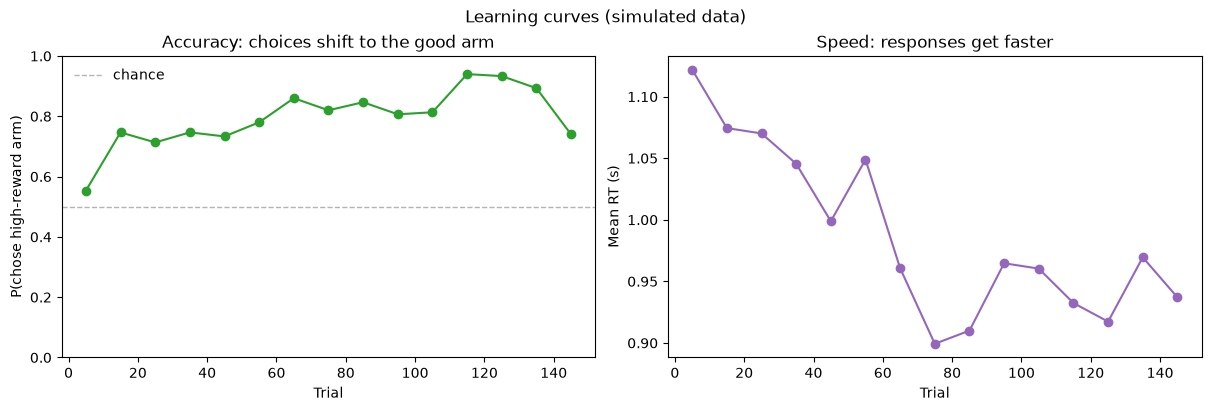

In [7]:
BIN = 10
learn = data[data["rt"] > 0].copy()
learn["chose_high"] = (learn["response"] == -1).astype(float)   # -1 == high-reward arm
learn["trial_bin"] = (learn["trial_id"] // BIN) * BIN
acc_curve = learn.groupby("trial_bin")["chose_high"].mean()
rt_curve = learn.groupby("trial_bin")["rt"].mean()
centers = acc_curve.index + BIN / 2

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(centers, acc_curve.values, "o-", color="tab:green")
axes[0].axhline(0.5, color="0.7", ls="--", lw=1, label="chance")
axes[0].set(xlabel="Trial", ylabel="P(chose high-reward arm)",
            title="Accuracy: choices shift to the good arm", ylim=(0, 1))
axes[0].legend(frameon=False)

axes[1].plot(centers, rt_curve.values, "o-", color="tab:purple")
axes[1].set(xlabel="Trial", ylabel="Mean RT (s)",
            title="Speed: responses get faster")
fig.suptitle("Learning curves (simulated data)")
plt.show()

## 6. Bridge the model into HSSM

Here is the step that PR-era HSSM makes easy. `RLSSMConfig.from_ssms_model` takes the
**same** `ssms` model we simulated from and produces an HSSM configuration object.
Nothing about the model is re-specified by hand — the learning rule, the decision
process, the parameter list, and the crucial "`v` is computed, not free" fact all
carry over automatically.

In [8]:
model_config = hssm.rl.RLSSMConfig.from_ssms_model(ssms_config)

print("list_params (free params HSSM will estimate):", model_config.list_params)
print("extra_fields (columns read from data):       ", model_config.extra_fields)
print("computed (driven by the learner, not free):  ", set(model_config.ssm_logp_func.computed))

# Sanity check: the drift v is computed by the learner and is NOT a free parameter.
assert "v" in model_config.ssm_logp_func.computed
assert "v" not in model_config.list_params

list_params (free params HSSM will estimate): ['rl_alpha', 'scaler', 'a', 'z', 't', 'theta']
extra_fields (columns read from data):        ['feedback']
computed (driven by the learner, not free):   {'v'}


`model_config` is plain, inspectable **metadata** — parameter names, bounds, which
columns are read from the data, and which SSM inputs are computed by the learner. In
this basic tutorial we use it as-is; the later tutorials show how *editing* this
object (or the underlying `ssms` model) lets you build entirely custom RLSSMs.

## 7. Specify hierarchical priors and build the model

For each parameter we write a small **`hssm.Param`** describing a hierarchical
structure with a formula borrowed from regression notation:

```
rl_alpha ~ 1 + (1 | participant_id)
```

Read it as: *"estimate a group-level intercept (`1`) plus a per-participant deviation
(`(1 | participant_id)`)."* We attach two priors:

- **`Intercept`** — a `TruncatedNormal` prior on the group mean, truncated to the
  parameter's valid range. This encodes a plausible starting guess without hard-coding
  the answer.
- **`1|participant_id`** — the spread of individual deviations. We give it mean **0**
  (so the group `Intercept` alone owns the overall location — this avoids a
  non-identifiability between the two) and a `HalfNormal` prior on how large the
  between-participant spread is.

The helper below just stamps out this same structure for each parameter so the model
call stays readable.

In [9]:
# Prior on the per-participant deviations: mean 0, with a learned spread (sigma).
PARTICIPANT_EFFECT_PRIOR = {
    "name": "Normal",
    "mu": 0,
    "sigma": {"name": "HalfNormal", "sigma": 0.5},
}


def hierarchical_param(name, lower, upper, mu, sigma):
    "A group intercept (TruncatedNormal) + per-participant random effect."
    return hssm.Param(
        name,
        formula=f"{name} ~ 1 + (1|participant_id)",
        prior={
            "Intercept": hssm.Prior("TruncatedNormal", lower=lower, upper=upper,
                                     mu=mu, sigma=sigma),
            "1|participant_id": PARTICIPANT_EFFECT_PRIOR,
        },
    )

Now we build the model. A few arguments deserve a note:

- **`data`** and **`model_config`** wire the trial panel to the bridged model.
- **`p_outlier=0` / `lapse=None`** turn off the outlier/lapse mixture — one fewer
  moving part for a first fit.
- **`process_initvals=False`** is **important for RLSSMs.** It tells HSSM to start the
  sampler from the prior rather than from processed initial values; the latter can
  place the RLSSM chain in a bad region where the gradient explodes and sampling
  stalls. (If you ever see the sampler make no progress with near-zero step size,
  this is the first thing to set.)

In [10]:
model = hssm.RLSSM(
    data=data,
    model_config=model_config,
    p_outlier=0,
    lapse=None,
    process_initvals=False,
    include=[
        hierarchical_param("rl_alpha", 0.01, 1.0, 0.15, 0.15),
        hierarchical_param("scaler", 0.1, 5.0, 2.0, 0.8),
        hierarchical_param("a", 0.3, 2.5, 1.1, 0.3),
        hierarchical_param("z", 0.1, 0.9, 0.5, 0.15),
        hierarchical_param("t", 0.05, 1.0, 0.25, 0.1),
        hierarchical_param("theta", 0.0, 1.2, 0.35, 0.15),
    ],
)

print("participants:", model.n_participants, "| trials/participant:", model.n_trials)
print("free parameters:", list(model.params.keys()))
assert "rl_alpha" in model.params
assert "v" not in model.params   # computed by the learner, never sampled

You supplied a model '2AB_RW_Angle', which is currently not supported in the ssm_simulators package. An error will be thrown when sampling from the random variable or when using any posterior or prior predictive sampling methods.


Model initialized successfully.


participants: 15 | trials/participant: 150
free parameters: ['rl_alpha', 'scaler', 'a', 'z', 't', 'theta']


HSSM builds on **bambi** (formula layer) and **PyMC** (sampling engine). You can
inspect both — handy for confirming the priors and likelihood wired up as intended:

In [11]:
print(model.model)

       Formula: c(rt, response) ~ 1 + (1|participant_id)
                scaler ~ 1 + (1|participant_id)
                a ~ 1 + (1|participant_id)
                z ~ 1 + (1|participant_id)
                t ~ 1 + (1|participant_id)
                theta ~ 1 + (1|participant_id)
        Family: SSM Family
          Link: rl_alpha = identity
                scaler = identity
                a = identity
                z = identity
                t = identity
                theta = identity
  Observations: 2250
        Priors: 
    target = rl_alpha
        Common-level effects
            Intercept ~ TruncatedNormal(lower: 0.009999999776482582, upper: 1.0, mu: 0.15000000596046448,
                sigma: 0.15000000596046448)
        
        
        Group-level effects
            1|participant_id ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 0.5))
    target = scaler
        Common-level effects
            scaler_Intercept ~ TruncatedNormal(lower: 0.10000000149011612, upper: 5.0, mu:

## 8. Sample the posterior

We draw from the posterior with the **NumPyro NUTS** sampler (fast, JAX-based). This
is the step that "learns" the parameters from data. At `FULL_RUN` scale this takes a
few minutes; at doc scale it is deliberately short.

In [12]:
idata = model.sample(
    sampler="numpyro",
    draws=N_DRAWS,
    tune=N_TUNE,
    chains=N_CHAINS,
    cores=N_CHAINS,
    target_accept=0.9,
    random_seed=RANDOM_SEED,
)
idata

Using default initvals. 



NUTS[numpyro]: [rl_alpha_Intercept, rl_alpha_1|participant_id_sigma, rl_alpha_1|participant_id_offset, scaler_Intercept, scaler_1|participant_id_sigma, scaler_1|participant_id_offset, a_Intercept, a_1|participant_id_sigma, a_1|participant_id_offset, z_Intercept, z_1|participant_id_sigma, z_1|participant_id_offset, t_Intercept, t_1|participant_id_sigma, t_1|participant_id_offset, theta_Intercept, theta_1|participant_id_sigma, theta_1|participant_id_offset]


  0%|          | 0/1500 [00:00<?, ?it/s]

warmup:   0%|          | 0/1500 [00:10<?, ?it/s, 255 steps of size 2.06e-02. acc. prob=0.84]

warmup:   3%|▎         | 42/1500 [00:10<05:49,  4.17it/s, 127 steps of size 1.03e-02. acc. prob=0.83]

...

sample: 100%|██████████| 1500/1500 [06:16<00:00,  3.99it/s, 63 steps of size 7.17e-02. acc. prob=0.92]

There were 26 divergences after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:                                (chain: 2, draw: 500,
│                                                   participant_id__factor_dim: 15,
│                                                   rl_alpha_1|participant_id__factor_dim: 15)
│       Coordinates:
│         * chain                                  (chain) int64 16B 0 1
│         * draw                                   (draw) int64 4kB 0 1 2 ... 498 499
│         * participant_id__factor_dim             (participant_id__factor_dim) <U2 120B ...
│         * rl_alpha_1|participant_id__factor_dim  (rl_alpha_1|participant_id__factor_dim) <U2 120B ...
│       Data variables: (12/24)
│           t_1|participant_id_offset              (chain, draw, participant_id__factor_dim) float32 60kB ...
│           z_1|participant_id                     (chain, draw, participant_id__factor_dim) float32 60kB ...
│           z_1|participant_id_sigma               (chain, draw) float32 4kB ...
│           theta_1|participant_id                 (chain, draw, participant_id__factor_dim) float32 60kB ...
│           rl_alpha_Intercept                     (chain, draw) float32 4kB ...
│           t_Intercept                            (chain, draw) float32 4kB ...
│           ...                                     ...
│           theta_1|participant_id_offset          (chain, draw, participant_id__factor_dim) float32 60kB ...
│           a_1|participant_id_offset              (chain, draw, participant_id__factor_dim) float32 60kB ...
│           t_1|participant_id_sigma               (chain, draw) float32 4kB ...
│           t_1|participant_id                     (chain, draw, participant_id__factor_dim) float32 60kB ...
│           scaler_1|participant_id_offset         (chain, draw, participant_id__factor_dim) float32 60kB ...
│           rl_alpha_1|participant_id_offset       (chain, draw, rl_alpha_1|participant_id__factor_dim) float32 60kB ...
│       Attributes:
│           created_at:                  2026-07-06T16:44:41.787695+00:00
│           creation_library:            ArviZ
│           creation_library_version:    1.2.0
│           creation_library_language:   Python
│           sample_dims:                 ['chain', 'draw']
│           inference_library:           numpyro
│           inference_library_version:   0.21.0
│           sampling_time:               545.10303
│           tuning_steps:                1000
│           modeling_interface:          bambi
│           modeling_interface_version:  0.18.0
├── Group: /sample_stats
│       Dimensions:          (chain: 2, draw: 500)
│       Coordinates:
│         * chain            (chain) int64 16B 0 1
│         * draw             (draw) int64 4kB 0 1 2 3 4 5 6 ... 494 495 496 497 498 499
│       Data variables:
│           acceptance_rate  (chain, draw) float32 4kB ...
│           step_size        (chain, draw) float32 4kB ...
│           diverging        (chain, draw) bool 1kB ...
│           energy           (chain, draw) float32 4kB ...
│           n_steps          (chain, draw) int32 4kB ...
│           tree_depth       (chain, draw) int64 8kB 6 6 6 6 6 6 6 6 ... 6 6 6 6 6 6 6 6
│           lp               (chain, draw) float32 4kB ...
│       Attributes:
│           created_at:                  2026-07-06T16:44:41.799808+00:00
│           creation_library:            ArviZ
│           creation_library_version:    1.2.0
│           creation_library_language:   Python
│           sample_dims:                 ['chain', 'draw']
│           modeling_interface:          bambi
│           modeling_interface_version:  0.18.0
├── Group: /observed_data
│       Dimensions:                  (__obs__: 2250, rt,response_extra_dim_0: 2)
│       Coordinates:
│         * __obs__                  (__obs__) int64 18kB 0 1 2 3 ... 2247 2248 2249
│         * rt,response_extra_dim_0  (rt,response_extra_dim_0) int64 16B 0 1
│       Data variables:
│           rt,response          

## 9. Parameter recovery

The real test: does the fitted model recover the parameters we simulated from? We
check at two levels — the **group means** and the **individual participants**. The
two helpers below do the plotting; the logic they rely on is simple because HSSM used
an *identity* link for every parameter here, so a participant's estimate is just
`Intercept + (their deviation)` on the natural scale.

In [13]:
def group_recovery(idata, true_group):
    "Group intercept posterior vs. true group mean, per parameter."
    names = [f"{p}_Intercept" for p in LIST_PARAMS]
    summ = az.summary(
        idata, var_names=names, kind="stats",
        ci_kind="hdi", ci_prob=0.94, round_to="none",
    )
    summ.index = LIST_PARAMS
    summ["true"] = [true_group[p] for p in LIST_PARAMS]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    y = np.arange(len(LIST_PARAMS))
    ax.errorbar(summ["mean"], y,
                xerr=[summ["mean"] - summ["hdi94_lb"], summ["hdi94_ub"] - summ["mean"]],
                fmt="o", capsize=4, label="posterior (94% HDI)")
    ax.scatter(summ["true"], y, color="crimson", marker="D", zorder=5,
               label="true group mean")
    ax.set_yticks(y); ax.set_yticklabels(LIST_PARAMS); ax.invert_yaxis()
    ax.set_title("Group-level recovery"); ax.legend()
    fig.tight_layout(); plt.show()
    return summ


def participant_recovery(idata, true_params):
    "Per-participant true vs. posterior-mean estimate, one panel per parameter."
    post = idata.posterior
    fig, axes = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)
    for ax, name in zip(axes.ravel(), LIST_PARAMS):
        re = post[f"{name}_1|participant_id"]
        pid_dim = [d for d in re.dims if d not in ("chain", "draw")][0]
        draws = post[f"{name}_Intercept"] + re          # identity link -> natural scale
        rec_mean = draws.mean(("chain", "draw")).values
        lo = draws.quantile(0.03, ("chain", "draw")).values
        hi = draws.quantile(0.97, ("chain", "draw")).values
        ids = [int(v) for v in re[pid_dim].values]
        true_v = true_params.loc[ids, name].values

        ax.errorbar(true_v, rec_mean,
                    yerr=[rec_mean - lo, hi - rec_mean],
                    fmt="o", ecolor="0.7", capsize=3)
        lohi = [min(true_v.min(), rec_mean.min()) - 0.03,
                max(true_v.max(), rec_mean.max()) + 0.03]
        ax.plot(lohi, lohi, "k--", lw=1)
        ax.set_title(name); ax.set_xlabel("true"); ax.set_ylabel("recovered")
        ax.grid(alpha=0.3)
    fig.suptitle("Participant-level recovery (points on the dashed line = perfect)")
    plt.show()

### 9.1 Group-level recovery

Each posterior interval (blue) should sit close to the corresponding true group mean
(red diamond).

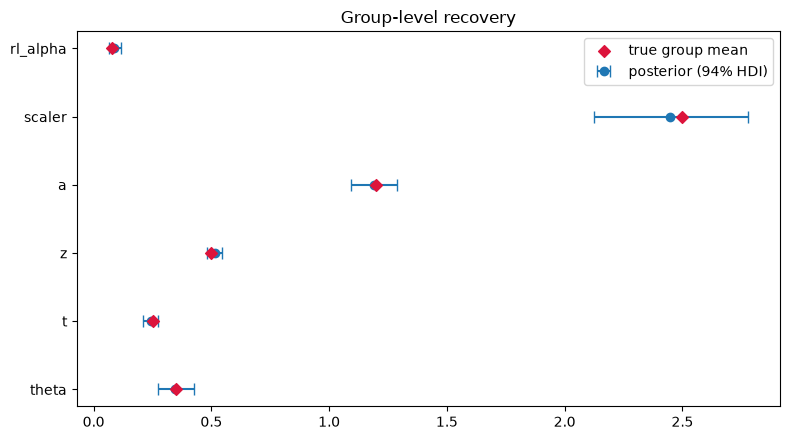

,mean,hdi94_lb,hdi94_ub,true
rl_alpha,0.088,0.064,0.115,0.08
scaler,2.447,2.125,2.779,2.50
a,1.190,1.091,1.288,1.20
z,0.515,0.483,0.546,0.50
t,0.244,0.210,0.273,0.25
theta,0.346,0.274,0.424,0.35


In [14]:
group_summary = group_recovery(idata, GROUP_THETA)
group_summary[["mean", "hdi94_lb", "hdi94_ub", "true"]].round(3)

### 9.2 Participant-level recovery

The stronger test: for each parameter, do the **individual** estimates track the
individual true values? Points hugging the dashed identity line indicate good
recovery. The decision parameters `a` and `z` are typically recovered most sharply
from choice+RT data; the learning parameters are harder and their points scatter more
— an honest reflection of how much a bandit task constrains them.

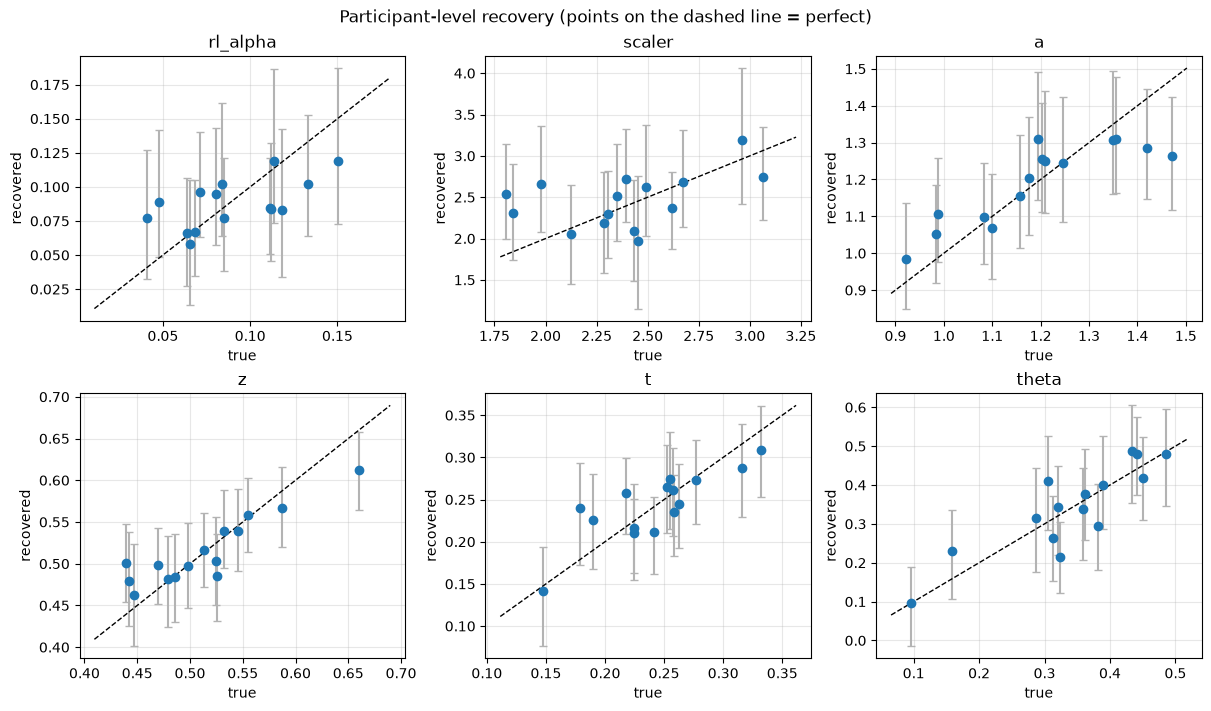

In [15]:
participant_recovery(idata, true_params)

## 10. Posterior predictive check (RLSSM-aware)

A posterior predictive check (PPC) asks: *if we simulate new data from the fitted
parameters, does it look like the data we observed?* For an RLSSM there is a subtlety.
Generic posterior predictive sampling would ignore the reward history and let the
learner wander freely, producing learning trajectories unlike the participant's. The
`ssms.rl` simulator therefore offers **`mode="ppc"`**, which **re-simulates each trial
while conditioning the learning trajectory on the participant's *observed* responses
and feedback.** In other words, it replays the real sequence of outcomes to keep the
Q-values on the same path the participant actually experienced, and only the SSM
choice/RT for each trial are freshly simulated from posterior parameters. This
isolates *decision* fit from extra bandit randomness.

We draw several parameter sets from the posterior, run `mode="ppc"` for each, and
compare the predicted learning curve and RT distribution to the observed data.

In [16]:
def draw_posterior_theta(idata, draw_idx):
    "A single posterior draw of per-participant parameters (natural scale)."
    posterior = idata.posterior
    if hasattr(posterior, "to_dataset"):
        posterior = posterior.to_dataset()  # PyMC 6 returns a DataTree node
    post = posterior.stack(sample=("chain", "draw"))
    theta = {}
    for name in LIST_PARAMS:
        re = post[f"{name}_1|participant_id"]
        pid_dim = [d for d in re.dims if d not in ("sample",)][0]
        vals = (post[f"{name}_Intercept"] + re).isel(sample=draw_idx)
        ids = [int(v) for v in re[pid_dim].values]
        s = pd.Series(np.asarray(vals.values), index=ids).sort_index()
        theta[name] = s.reindex(range(N_PARTICIPANTS)).to_numpy()
    return theta


N_PPC_DRAWS = 20 if FULL_RUN else 8
n_samples = idata.posterior.sizes["chain"] * idata.posterior.sizes["draw"]
ppc_rng = np.random.default_rng(RANDOM_SEED + 1)
draw_ids = ppc_rng.choice(n_samples, size=min(N_PPC_DRAWS, n_samples), replace=False)

ppc_frames = []
for k, d in enumerate(draw_ids):
    theta_d = draw_posterior_theta(idata, int(d))
    ppc_d = rl.Simulator(ssms_config).simulate(
        theta=theta_d, mode="ppc", observed_data=data,
        random_state=RANDOM_SEED + 100 + k,
    )
    ppc_d["ppc_draw"] = k
    ppc_frames.append(ppc_d)
ppc_data = pd.concat(ppc_frames, ignore_index=True)
print("PPC datasets:", len(draw_ids), "| total rows:", len(ppc_data))

PPC datasets: 20 | total rows: 45000


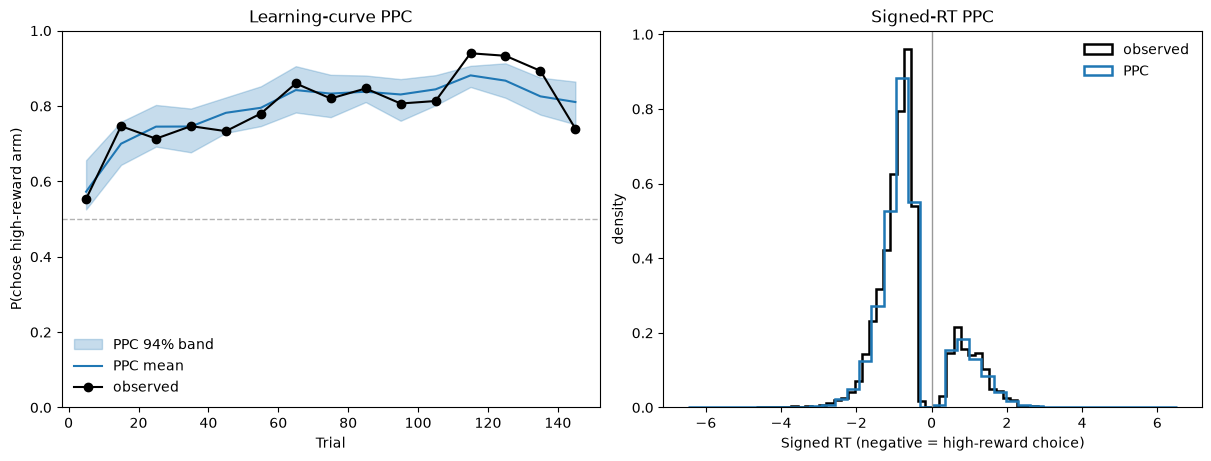

In [17]:
def learning_curve(df, bin_size=10):
    d = df[df["rt"] > -900].copy()
    d["chose_high"] = (d["response"] == -1).astype(float)   # -1 == high-reward arm
    d["trial_bin"] = (d["trial_id"] // bin_size) * bin_size
    return d.groupby("trial_bin")["chose_high"].mean()


def signed_rt(df):
    d = df[df["rt"] > -900].copy()
    # sign encodes choice: negative = high-reward arm (-1), positive = low-reward arm
    return np.where(d["response"].astype(int) == -1,
                    -d["rt"].astype(float), d["rt"].astype(float))


fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

# (a) Learning-curve PPC: observed vs. per-draw predicted band
obs_curve = learning_curve(data)
ppc_curves = pd.concat(
    [learning_curve(g).rename(k) for k, g in ppc_data.groupby("ppc_draw")], axis=1
).sort_index()
centers = obs_curve.index + 5
axes[0].fill_between(ppc_curves.index + 5,
                     ppc_curves.quantile(0.03, axis=1),
                     ppc_curves.quantile(0.97, axis=1),
                     alpha=0.25, color="tab:blue", label="PPC 94% band")
axes[0].plot(ppc_curves.index + 5, ppc_curves.mean(axis=1), color="tab:blue",
             lw=1.5, label="PPC mean")
axes[0].plot(centers, obs_curve.values, "o-", color="black", label="observed")
axes[0].axhline(0.5, color="0.7", ls="--", lw=1)
axes[0].set(xlabel="Trial", ylabel="P(chose high-reward arm)",
            title="Learning-curve PPC", ylim=(0, 1))
axes[0].legend(frameon=False)

# (b) Signed-RT PPC: observed vs. pooled predicted
axes[1].hist(signed_rt(data), bins=40, density=True, histtype="step", lw=1.8,
             color="black", label="observed")
axes[1].hist(signed_rt(ppc_data), bins=40, density=True, histtype="step", lw=1.8,
             color="tab:blue", label="PPC")
axes[1].axvline(0, color="0.6", lw=1)
axes[1].set(xlabel="Signed RT (negative = high-reward choice)", ylabel="density",
            title="Signed-RT PPC")
axes[1].legend(frameon=False)
plt.show()

## 11. Summary

You have run a complete RLSSM workflow:

1. **Chose a model** — the `2AB_RW_Angle` preset (Rescorla–Wagner learning + angle SSM).
2. **Simulated** a hierarchical dataset from known parameters and confirmed learning.
3. **Bridged** it into HSSM with a single `RLSSMConfig.from_ssms_model` call — the
   learned drift `v` is *computed*, never fit.
4. **Fit** a hierarchical model with NumPyro (remembering `process_initvals=False`).
5. **Checked recovery** at the group and individual level.
6. **Ran an RLSSM-aware PPC** with `mode="ppc"`, which conditions the learning
   trajectory on the observed reward history.

### Where to go next

- **[Custom models with ssms.rl](rlssm_advanced.ipynb)** — build your own task
  environment and learning rule instead of using a preset.
- **[Restless learner](rlssm_restless_learner.ipynb)** — one learner driving *several*
  decision parameters at once.
- **[Registering custom models in HSSM](rlssm_hssm_custom_models.ipynb)** — the
  HSSM-native registry path.

> **Note:** HSSM also supports *choice-only* reinforcement-learning models (no RT).
> Those are documented separately once fully validated against the current release.